GROWTH EXPERIMENTATION ENGINE

EDA & Business Understanding

Objective:
- Understand dataset structure
- Validate data quality
- Explore experiment distribution
- Explore country distribution
- Build executive-level visualizations
- Prepare data for experiment analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
df = pd.read_csv("../data/clean_experiment_data.csv")

print("Rows and Columns:")
print(df.shape)

df.head()

Rows and Columns:
(290585, 6)


,id,time,con_treat,page,converted,country
0,851104,11:48.6,control,old_page,0,US
1,804228,01:45.2,control,old_page,0,US
2,661590,55:06.2,treatment,new_page,0,US
3,853541,28:03.1,treatment,new_page,0,US
4,864975,52:26.2,control,old_page,1,US


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290585 entries, 0 to 290584
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   id         290585 non-null  int64
 1   time       290585 non-null  str  
 2   con_treat  290585 non-null  str  
 3   page       290585 non-null  str  
 4   converted  290585 non-null  int64
 5   country    290585 non-null  str  
dtypes: int64(2), str(4)
memory usage: 13.3 MB


In [4]:
df.isnull().sum()

id           0
time         0
con_treat    0
page         0
converted    0
country      0
dtype: int64

In [13]:
mismatch = df[
    ((df['con_treat']=='treatment') & (df['page']=='old_page'))
    |
    ((df['con_treat']=='control') & (df['page']=='new_page'))
]

print("Mismatches Found:", len(mismatch))

Mismatches Found: 0


In [14]:
df.describe(include='all')

,id,time,con_treat,page,converted,country
count,290585.000000,290585,290585,290585,290585.000000,290585
unique,NaN,35991,2,2,NaN,3
top,NaN,33:53.2,treatment,new_page,NaN,US
freq,NaN,22,145311,145311,NaN,203620
mean,788004.825246,NaN,NaN,NaN,0.119597,NaN
std,91224.582639,NaN,NaN,NaN,0.324490,NaN
min,630000.000000,NaN,NaN,NaN,0.000000,NaN
25%,709035.000000,NaN,NaN,NaN,0.000000,NaN
50%,787995.000000,NaN,NaN,NaN,0.000000,NaN
75%,866956.000000,NaN,NaN,NaN,0.000000,NaN


In [15]:
experiment_split = (
    df['con_treat']
    .value_counts()
)

experiment_split

con_treat
treatment    145311
control      145274
Name: count, dtype: int64

In [16]:
country_distribution = (
    df['country']
    .value_counts()
)

country_distribution

country
US    203620
UK     72466
CA     14499
Name: count, dtype: int64

In [22]:
country_share = (
    df['country']
    .value_counts(normalize=True)
    *100
)

country_share.round(2)

country
US    70.07
UK    24.94
CA     4.99
Name: proportion, dtype: float64

In [23]:
conversion_distribution = (
    df['converted']
    .value_counts()
)

conversion_distribution

converted
0    255832
1     34753
Name: count, dtype: int64

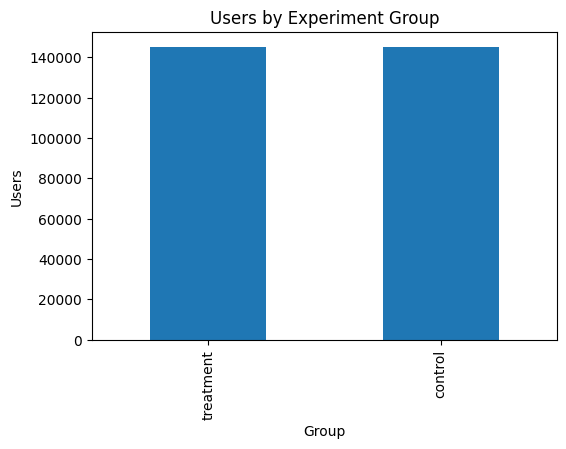

In [24]:
plt.figure(figsize=(6,4))

df['con_treat'].value_counts().plot(
    kind='bar'
)

plt.title("Users by Experiment Group")
plt.xlabel("Group")
plt.ylabel("Users")

plt.show()

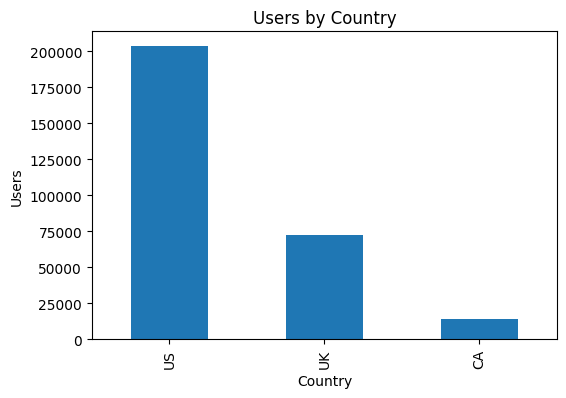

In [25]:
plt.figure(figsize=(6,4))

df['country'].value_counts().plot(
    kind='bar'
)

plt.title("Users by Country")
plt.xlabel("Country")
plt.ylabel("Users")

plt.show()

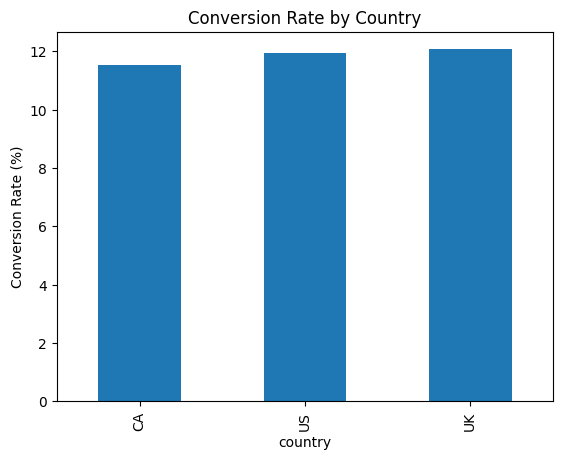

In [26]:
country_cvr = (
    df.groupby('country')['converted']
    .mean()
    *100
)

country_cvr.sort_values().plot(
    kind='bar'
)

plt.title("Conversion Rate by Country")
plt.ylabel("Conversion Rate (%)")

plt.show()

In [27]:
print("="*50)

print("EXECUTIVE SUMMARY")

print("="*50)

print(f"Total Users: {len(df):,}")

print()

print("Experiment Groups:")
print(df['con_treat'].value_counts())

print()

print("Countries:")
print(df['country'].value_counts())

print()

print("Overall Conversion Rate:")
print(round(df['converted'].mean()*100,2),"%")

EXECUTIVE SUMMARY
Total Users: 290,585

Experiment Groups:
con_treat
treatment    145311
control      145274
Name: count, dtype: int64

Countries:
country
US    203620
UK     72466
CA     14499
Name: count, dtype: int64

Overall Conversion Rate:
11.96 %
